# Skin Cancer Classification for Detecting Melanoma

## 1. Preprocessing

In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
len(train_targets), len(valid_targets)

(900, 400)

### 1.1. Data preprocessing

In [6]:
# import os
# os.environ['KERAS_BACKEND'] = 'tensorflow'
# import tensorflow as tf
# config = tf.compat.v1.ConfigProto()
# config.gpu_options.allow_growth = True
# sess = tf.compat.v1.Session(config=config)
# tf.compat.v1.keras.backend.set_session(sess)

In [7]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession
config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)

In [8]:
# Importing the libraries
import numpy as np
import pandas as pd
import os
from sklearn.datasets import load_files
from keras.utils import np_utils 

In [9]:
# # Load text files with categories as subfolder names.
# path = "./Dataset/"
# data = load_files(path)

In [10]:
# print("Filename: \n", data['filenames'][:405])
# print("Targets: \n", data['target'][:405])

In [11]:
# data['target']

In [12]:
# from collections import Counter
 
# # Creation of a Counter Class object using
# # string as an iterable data container
# Counter(data['target'][:300])

In [13]:
# Getting the labels
# target = np_utils.to_categorical(np.array(data['target']), 2)
# target
# from tensorflow.keras.utils import to_categorical
# target = to_categorical(np.array(data['target']), num_classes=2)
# target

In [14]:
# len(data['filenames'])

In [15]:
# # Splitting the data into the training and validation set
# train_files, train_targets = data['filenames'][:300], data['target'][:300]
# valid_files, valid_targets = data['filenames'][300:], data['target'][300:]

In [16]:
# Counter(train_targets)

### 1.2. Image preprocessing

In [17]:
# Importing the libraries
import keras
from keras.preprocessing import image          
from tqdm import tqdm
from PIL import ImageFile                            
ImageFile.LOAD_TRUNCATED_IMAGES = True                 

In [18]:
def path_to_tensor(img_path):
    """
    Getting a tensor from a given path.
    """
    # Loading the image
    img = image.load_img(img_path, target_size=(256, 256))
    # Converting the image to numpy array
    x = image.img_to_array(img)   
    # convert 3D tensor to 4D tensor with shape (1, 512, 512, 3)
    return np.expand_dims(x, axis=0)

def paths_to_tensor(img_paths):
    """
    # Getting a list of tensors from a given path directory.
    """
    list_of_tensors = [path_to_tensor(img_path) for img_path in tqdm(img_paths)]
    return np.vstack(list_of_tensors)

In [19]:
# # pre-process the data for Keras
# train_tensors = paths_to_tensor(train_files).astype('float32')/255
# valid_tensors = paths_to_tensor(valid_files).astype('float32')/255

In [20]:
# # Saving the data
# np.save("./Saved image tensors/augmented_training_tensors.npy", train_tensors)
# np.save("./Saved image tensors/augmented_validation_tensors.npy", valid_tensors)

In [21]:
# Loading the data
train_tensors = np.load("/content/drive/MyDrive/MAJOR project/Saved image tensors/augmented_training_tensors(0-900(16)).npy")
valid_tensors = np.load("/content/drive/MyDrive/MAJOR project/Saved image tensors/augmented_validation_tensors(900-1300(16)).npy")

## 2. Training the model

In [22]:
# # Importing the keras libraries
# import keras
# from keras.models import Model
# from keras.layers import Dense, GlobalAveragePooling2D, Flatten, BatchNormalization, Activation, Dropout
# from keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

In [23]:
train_targets = np.array(train_targets)
valid_targets = np.array(valid_targets)

In [24]:
train_targets

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [1., 0.]])

### 2.1. MobileNet architecture

In [25]:
def mobilenet_architecture():
    # """
    # Pre-build architecture of mobilenet for our dataset.
    # """
    # # Imprting the model
    # from keras.applications.mobilenet import MobileNet

    # # Pre-build model
    # base_model = MobileNet(include_top = False, weights = None, input_shape = (512, 512, 3))

    # # Adding output layers
    # x = base_model.output
    # x = GlobalAveragePooling2D()(x)
    # output = Dense(units = 2, activation = 'softmax')(x)

    # # Creating the whole model
    # mobilenet_model = Model(base_model.input, output)
    
    # # Getting the summary of architecture
    # #mobilenet_model.summary()
    
    # # Compiling the model
    # mobilenet_model.compile(optimizer = keras.optimizers.Adam(lr = 0.001), 
    #                         loss = 'categorical_crossentropy', 
    #                         metrics = ['accuracy'])

    base_model = MobileNet(include_top=False, weights=None, input_shape=(256, 256, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units=2, activation='softmax')(x)
    mobilenet_model = Model(base_model.input, output)
    mobilenet_model.compile(optimizer=Adam(learning_rate=0.001),
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])
    return mobilenet_model

In [26]:
# Getting the mobilenet
mobilenet_model = mobilenet_architecture()

In [ ]:
checkpointer = ModelCheckpoint(filepath="/content/drive/MyDrive/MAJOR project/Saved models/weights.best.mobilenet.hdf5", 
                               verbose=1, 
                               save_best_only=True)

mobilenet_model.fit(train_tensors, 
                    train_targets, 
                    batch_size = 1,
                    validation_data = (valid_tensors, valid_targets),
                    epochs = 5,
                    callbacks=[checkpointer], 
                    verbose=1)

In [ ]:
# Loading the weights
mobilenet_model.load_weights("/content/drive/MyDrive/MAJOR project/Saved models/weights.best.mobilenet.hdf5")

### 2.2. Inception architecture

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3
def inception_architecture():
    """
    Pre-build architecture of inception for our dataset.
    """
    # Imprting the model 
    # from keras.applications.inception_v3 import InceptionV3
    

    # Pre-build model
    base_model = InceptionV3(include_top = False, weights = None, input_shape = (512, 512, 3))

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    inception_model = Model(base_model.input, output)
    
    # Summary of the model
    #inception_model.summary()
    
    # Compiling the model
    inception_model.compile(optimizer = Adam(learning_rate = 0.001), 
                            loss = 'categorical_crossentropy', 
                            metrics = ['accuracy'])
    
    return inception_model

In [ ]:
# Getting the inception
inception_model = inception_architecture()

In [ ]:
checkpointer = ModelCheckpoint(filepath='Saved models/weights.best.inception.hdf5', 
                               verbose=1, 
                               save_best_only=True)

inception_model.fit(train_tensors, 
                    train_targets, 
                    batch_size = 2,
                    validation_data = (valid_tensors, valid_targets),
                    epochs = 5,
                    callbacks=[checkpointer], 
                    verbose=1)

Epoch 1/5
225/225 [==============================] - 31s 93ms/step - loss: 0.9448 - accuracy: 0.5644 - val_loss: 6.9500 - val_accuracy: 0.4035

Epoch 00001: val_loss improved from inf to 6.95001, saving model to Saved models\weights.best.inception.hdf5
Epoch 2/5
225/225 [==============================] - 19s 83ms/step - loss: 0.7509 - accuracy: 0.5867 - val_loss: 4.0776 - val_accuracy: 0.5088

Epoch 00002: val_loss improved from 6.95001 to 4.07765, saving model to Saved models\weights.best.inception.hdf5
Epoch 3/5
225/225 [==============================] - 19s 84ms/step - loss: 0.6682 - accuracy: 0.6333 - val_loss: 0.5606 - val_accuracy: 0.7193

Epoch 00003: val_loss improved from 4.07765 to 0.56058, saving model to Saved models\weights.best.inception.hdf5
Epoch 4/5
225/225 [==============================] - 19s 86ms/step - loss: 0.6764 - accuracy: 0.6111 - val_loss: 1.3813 - val_accuracy: 0.6667

Epoch 00004: val_loss did not improve from 0.56058
Epoch 5/5
225/225 [===================

In [ ]:
# Loading the weights
inception_model.load_weights("./Saved models/weights.best.inception.hdf5")

### 2.3. Xception architecture

In [ ]:
from tensorflow.keras.applications.xception import Xception
def xception_architecture():
    """
    Pre-build architecture of inception for our dataset.
    """
    # Imprting the model
    # from keras.applications.xception import Xception
    
    
    # Pre-build model
    base_model = Xception(include_top = False, weights = None, input_shape = (512, 512, 3))

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    xception_model = Model(base_model.input, output)

    # Summary of the model
    #xception_model.summary()
    
    # Compiling the model
    xception_model.compile(optimizer = Adam(learning_rate = 0.001), 
                           loss = 'categorical_crossentropy', 
                           metrics = ['accuracy'])

    return xception_model

In [ ]:
# Getting the xception
xception_model = xception_architecture()

In [ ]:
# from tensorflow.keras.callbacks import Tensorboard
# tensor_board = TensorBoard(log_dir='./logs', histogram_freq = 0, batch_size = 8)

checkpointer = ModelCheckpoint(filepath='Saved models/weights.best.xception.hdf5', 
                               verbose=1, 
                               save_best_only=True)

xception_model.fit(train_tensors, 
                   train_targets, 
                   batch_size = 1,
                   validation_data = (valid_tensors, valid_targets),
                   epochs = 2,
                   callbacks=[checkpointer], #[checkpointer, tensor_board], 
                   verbose=1)

Epoch 1/2
450/450 [==============================] - 54s 97ms/step - loss: 0.8423 - accuracy: 0.5467 - val_loss: 0.8313 - val_accuracy: 0.5789

Epoch 00001: val_loss improved from inf to 0.83125, saving model to Saved models\weights.best.xception.hdf5


c:\Users\bmpra\anaconda3\envs\tf-gpu\lib\site-packages\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


Epoch 2/2
450/450 [==============================] - 43s 95ms/step - loss: 0.7314 - accuracy: 0.5311 - val_loss: 1.2229 - val_accuracy: 0.5789

Epoch 00002: val_loss did not improve from 0.83125


In [ ]:
# Loading the weights
xception_model.load_weights("./Saved models/weights.best.xception.hdf5")

## 3. Prediction

In [ ]:
model_architecture = mobilenet_architecture()
weight_path = "./Saved models/weights.best.mobilenet.hdf5"

In [ ]:
def predict(img_path, 
            model_architecture = model_architecture, 
            path_model_weight = weight_path):
    # Getting the tensor of image
    image_to_predict = path_to_tensor(img_path).astype('float32')/255
    # Getting the model's architecture
    model = model_architecture
    # Loading the weights
    model.load_weights(path_model_weight)
    # Predicting
    pred = model.predict(image_to_predict)
    print("Prediction..." + " Melanoma : ", pred[0][0], " | Other : ", pred[0][1])
    if np.argmax(pred) == 0:
        return [1., 0.]
    elif np.argmax(pred) == 1:
        return [0., 1.]

In [ ]:
predict("ISIC_0031649_nm.jpg")

Prediction... Melanoma :  0.1855855  | Other :  0.8144145


[0.0, 1.0]

In [ ]:
predict('./Dataset/melanoma/ISIC_0024310.jpg')

Prediction... Melanoma :  0.41210085  | Other :  0.58789915


[0.0, 1.0]

## 4. Evaluating the model

In [ ]:
# Importing the libraries
from sklearn.metrics import roc_curve, auc
import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def compute_roc(y_true, y_score):
    """ 
    Computing the "Receiving Operating Characteristic curve" and area
    """
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_true, y_score) 
    auroc = auc(false_positive_rate, true_positive_rate) 
    return false_positive_rate, true_positive_rate, auroc

In [ ]:
def plot_roc(y_true, y_score):
    """ 
    Ploting the Receiving Operating Characteristic curve
    """
    false_positive_rate, true_positive_rate, auroc = compute_roc(y_true, y_score)
    plt.figure(figsize=(10,6))
    plt.grid()
    plt.plot(false_positive_rate, 
             true_positive_rate, 
             color='darkorange',
             lw=2, 
             label='ROC curve (area = {:.2f})'.format(auroc))
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver operating characteristic example', fontsize=15)
    plt.legend(loc="lower right", fontsize=14)
    plt.show()

In [ ]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [ ]:
plt.style.use("seaborn-white")

C:\Users\bmpra\AppData\Local\Temp\ipykernel_13204\3081854136.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-white")


### 4.1. Evaluating MobileNet

In [ ]:
# Compute test set predictions
NUMBER_TEST_SAMPLES = 5

y_true = valid_targets[:NUMBER_TEST_SAMPLES]
y_score = []
for index in range(NUMBER_TEST_SAMPLES): #compute one at a time due to memory constraints
    probs = predict(img_path = valid_files[index])
    print("Real values..." + "Melanoma : ", valid_targets[index][0], " | Other : ", valid_targets[index][1])
    print("---------------------------------------------------------------------------")
    y_score.append(probs)
    
correct = np.array(y_true) == np.array(y_score)

Prediction... Melanoma :  0.21326753  | Other :  0.78673244
Real values...Melanoma :  0.0  | Other :  1.0
---------------------------------------------------------------------------
Prediction... Melanoma :  0.11920088  | Other :  0.8807992
Real values...Melanoma :  0.0  | Other :  1.0
---------------------------------------------------------------------------
Prediction... Melanoma :  0.78181374  | Other :  0.21818623
Real values...Melanoma :  1.0  | Other :  0.0
---------------------------------------------------------------------------
Prediction... Melanoma :  0.7012726  | Other :  0.29872742
Real values...Melanoma :  1.0  | Other :  0.0
---------------------------------------------------------------------------
Prediction... Melanoma :  0.4699078  | Other :  0.5300922
Real values...Melanoma :  1.0  | Other :  0.0
---------------------------------------------------------------------------


In [ ]:
print("Accuracy = %2.2f%%" % (np.mean(correct)*100))

Accuracy = 80.00%


In [ ]:
# Re-ordering the actual y (for ROC)
y_true_2 = []
for i in range(len(y_true)):
    y_true_2.append(y_true[i][0])

In [ ]:
# Re-ordering the predicte y (for ROC)
y_score_2 = []
for i in range(len(y_score)):
    y_score_2.append(y_score[i][0])

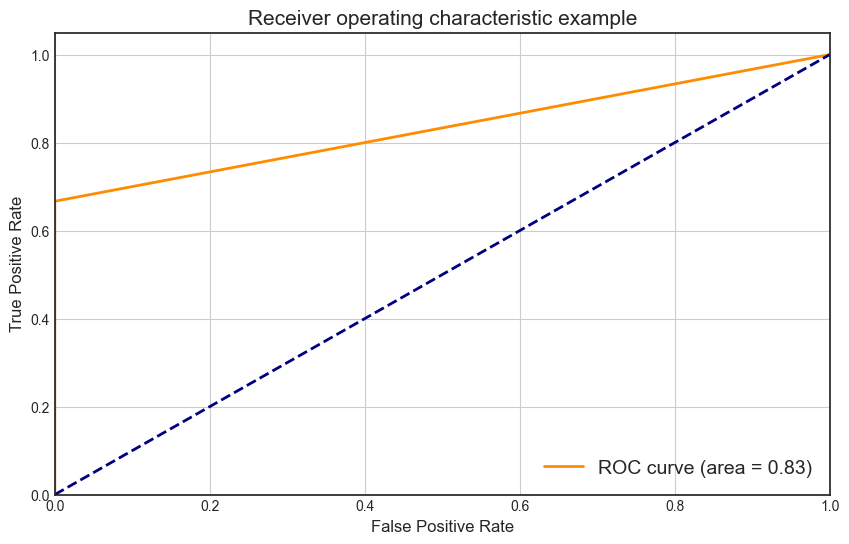

In [ ]:
plot_roc(y_true_2, y_score_2)

In [ ]:
def positive_negative_measurement(y_true, y_score):
    # Initialization
    TRUE_POSITIVE = 0
    FALSE_POSITIVE = 0
    TRUE_NEGATIVE = 0
    FALSE_NEGATIVE = 0
    
    # Calculating the model
    for i in range(len(y_score)):
        if y_true[i] == y_score[i] == 1:
            TRUE_POSITIVE += 1
        if (y_score[i] == 1) and (y_true[i] != y_score[i]):
            FALSE_POSITIVE += 1
        if y_true[i] == y_score[i] == 0:
            TRUE_NEGATIVE += 1
        if (y_score[i] == 0) and (y_true[i] != y_score[i]):
            FALSE_NEGATIVE += 1

    return(TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE)

In [ ]:
TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE = positive_negative_measurement(y_true_2, y_score_2)
postives_negatives = [[TRUE_POSITIVE, FALSE_POSITIVE], 
                      [FALSE_NEGATIVE, TRUE_NEGATIVE]]

<Axes: >

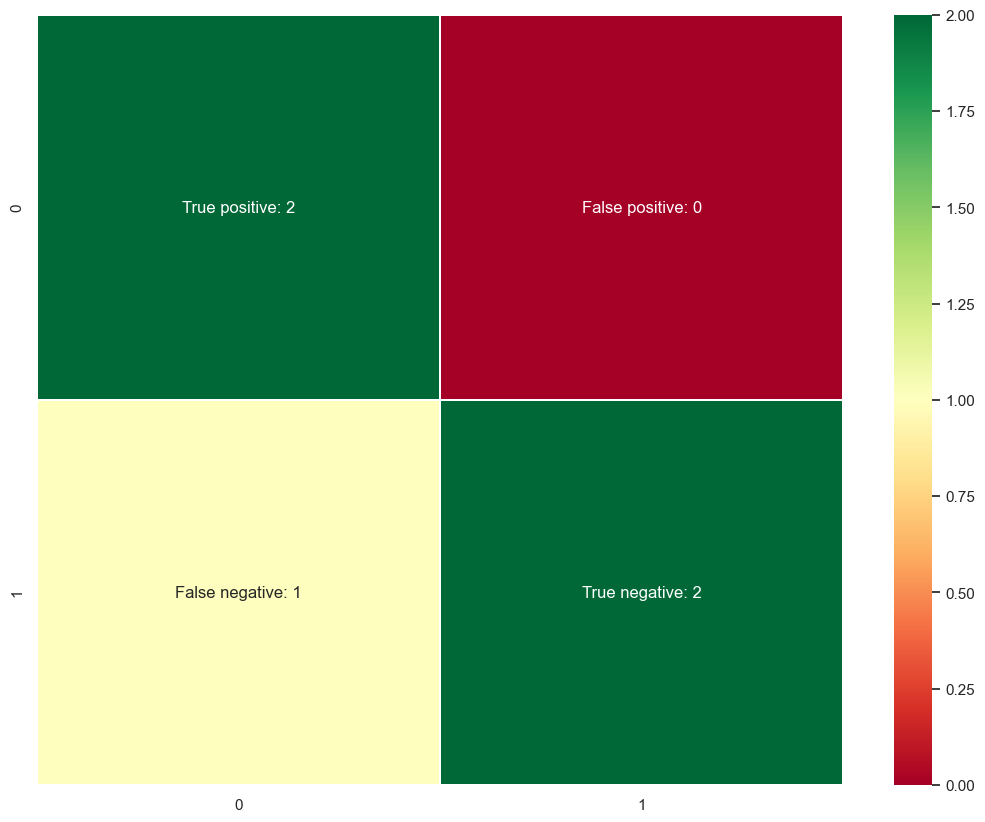

In [ ]:
import seaborn as sns
sns.set()
labels =  np.array([['True positive: ' + str(TRUE_POSITIVE),
                     'False positive: ' + str(FALSE_POSITIVE)],
                    ['False negative: ' + str(FALSE_NEGATIVE),
                     'True negative: ' + str(TRUE_POSITIVE)]])
plt.figure(figsize = (13, 10))
sns.heatmap(postives_negatives, annot = labels, linewidths = 0.1, fmt="", cmap = 'RdYlGn')

In [ ]:
# Sensitivity | Recall | hit rate | true positive rate (TPR)
sensitivity = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_NEGATIVE)
print("Sensitivity: ", sensitivity)

Sensitivity:  0.6666666666666666


In [ ]:
# Specificity | selectivity | true negative rate (TNR)
specifity = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Specifity: ", specifity)

Specifity:  0.6666666666666666


In [ ]:
# Precision | positive predictive value (PPV)
predcision = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_POSITIVE)
print("Precision: ", predcision)

Precision:  1.0


In [ ]:
# Negative predictive value (NPV)
npv = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Negative predictive value: ", npv)

Negative predictive value:  0.6666666666666666


In [ ]:
# Accuracy 
accuracy = (TRUE_POSITIVE + TRUE_NEGATIVE) / (TRUE_POSITIVE + FALSE_POSITIVE + TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Accuracy: ", accuracy)

Accuracy:  0.8


### 4.2. Evaluating Inception

In [ ]:
# Compute test set predictions
NUMBER_TEST_SAMPLES = 5

y_true = valid_targets[:NUMBER_TEST_SAMPLES]
y_score = []
for index in range(NUMBER_TEST_SAMPLES): #compute one at a time due to memory constraints
    probs = predict(img_path = valid_files[index])
    print("Real values {}...".format(index+1) + "Melanoma : ", valid_targets[index][0], " | Other : ", valid_targets[index][1])
    print("---------------------------------------------------------------------------")
    y_score.append(probs)
    
correct = np.array(y_true) == np.array(y_score)

Prediction... Melanoma :  0.21326753  | Other :  0.78673244
Real values 1...Melanoma :  0.0  | Other :  1.0
---------------------------------------------------------------------------
Prediction... Melanoma :  0.11920088  | Other :  0.8807992
Real values 2...Melanoma :  0.0  | Other :  1.0
---------------------------------------------------------------------------
Prediction... Melanoma :  0.78181374  | Other :  0.21818623
Real values 3...Melanoma :  1.0  | Other :  0.0
---------------------------------------------------------------------------
Prediction... Melanoma :  0.7012726  | Other :  0.29872742
Real values 4...Melanoma :  1.0  | Other :  0.0
---------------------------------------------------------------------------
Prediction... Melanoma :  0.4699078  | Other :  0.5300922
Real values 5...Melanoma :  1.0  | Other :  0.0
---------------------------------------------------------------------------


In [ ]:
print("Accuracy = %2.2f%%" % (np.mean(correct)*100))

Accuracy = 80.00%


In [ ]:
# Re-ordering the actual y (for ROC)
y_true_2 = []
for i in range(len(y_true)):
    y_true_2.append(y_true[i][0])
    
# Re-ordering the predicte y (for ROC)
y_score_2 = []
for i in range(len(y_score)):
    y_score_2.append(y_score[i][0])

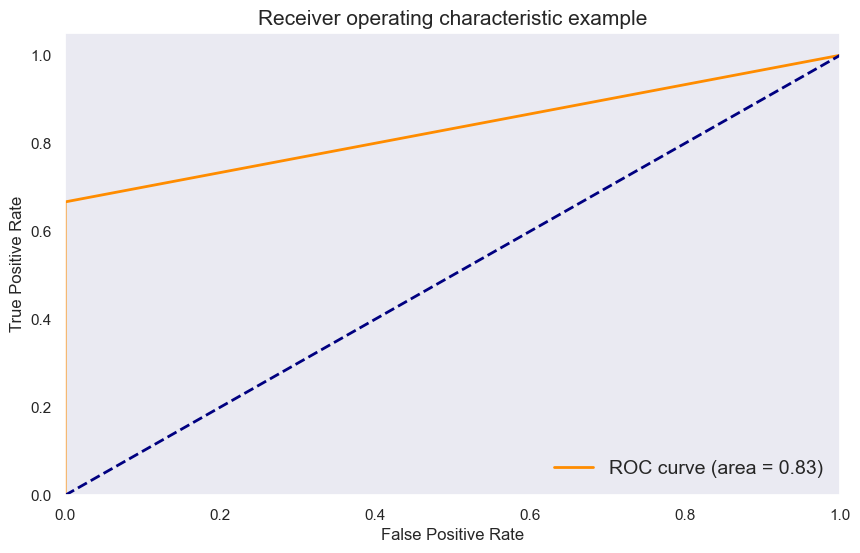

In [ ]:
plot_roc(y_true_2, y_score_2)

In [ ]:
def positive_negative_measurement(y_true, y_score):
    # Initialization
    TRUE_POSITIVE = 0
    FALSE_POSITIVE = 0
    TRUE_NEGATIVE = 0
    FALSE_NEGATIVE = 0
    
    # Calculating the model
    for i in range(len(y_score)):
        if y_true[i] == y_score[i] == 1:
            TRUE_POSITIVE += 1
        if (y_score[i] == 1) and (y_true[i] != y_score[i]):
            FALSE_POSITIVE += 1
        if y_true[i] == y_score[i] == 0:
            TRUE_NEGATIVE += 1
        if (y_score[i] == 0) and (y_true[i] != y_score[i]):
            FALSE_NEGATIVE += 1

    return(TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE)

In [ ]:
TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE = positive_negative_measurement(y_true_2, y_score_2)
postives_negatives = [[TRUE_POSITIVE, FALSE_POSITIVE], 
                      [FALSE_NEGATIVE, TRUE_NEGATIVE]]

<Axes: >

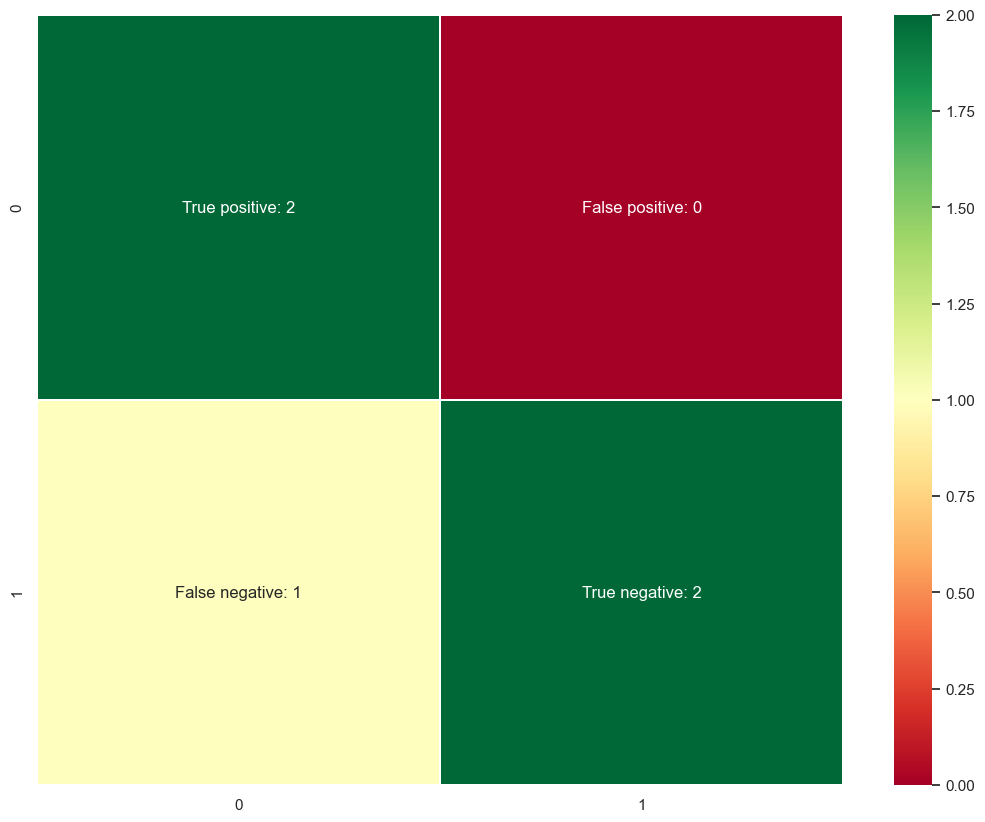

In [ ]:
import seaborn as sns
sns.set()
labels =  np.array([['True positive: ' + str(TRUE_POSITIVE),
                     'False positive: ' + str(FALSE_POSITIVE)],
                    ['False negative: ' + str(FALSE_NEGATIVE),
                     'True negative: ' + str(TRUE_POSITIVE)]])
plt.figure(figsize = (13, 10))
sns.heatmap(postives_negatives, annot = labels, linewidths = 0.1, fmt="", cmap = 'RdYlGn')

In [ ]:
# Sensitivity | Recall | hit rate | true positive rate (TPR)
sensitivity = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_NEGATIVE)
print("Sensitivity: ", sensitivity)

# Specificity | selectivity | true negative rate (TNR)
specifity = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Specifity: ", specifity)

# Precision | positive predictive value (PPV)
# predcision = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_POSITIVE)
# print("Precision: ", predcision)

# Negative predictive value (NPV)
npv = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Negative predictive value: ", npv)

# Accuracy 
accuracy = (TRUE_POSITIVE + TRUE_NEGATIVE) / (TRUE_POSITIVE + FALSE_POSITIVE + TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Accuracy: ", accuracy)

Sensitivity:  0.6666666666666666
Specifity:  0.6666666666666666
Negative predictive value:  0.6666666666666666
Accuracy:  0.8


## 5. Ensembling the models

In [ ]:
from tensorflow.keras.layers import Input

In [ ]:
# Single input for multiple models
model_input = Input(shape=(512, 512, 3))

In [ ]:
def mobilenet_architecture():
    """
    Pre-build architecture of mobilenet for our dataset.
    """
    # Imprting the model
    # from keras.applications.mobilenet import MobileNet

    # Pre-build model
    base_model = MobileNet(include_top = False, weights = None, input_tensor = model_input)

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    mobilenet_model = Model(base_model.input, output)
    
    # Getting the summary of architecture
    #mobilenet_model.summary()
    
    # Compiling the model
    mobilenet_model.compile(optimizer = Adam(learning_rate = 0.001), 
                            loss = 'categorical_crossentropy', 
                            metrics = ['accuracy'])

    return mobilenet_model

In [ ]:
# Model 1
mobilenet_model = mobilenet_architecture()
mobilenet_model.load_weights("./Saved models/weights.best.mobilenet.hdf5")

In [ ]:
def inception_architecture():
    """
    Pre-build architecture of inception for our dataset.
    """
    # Imprting the model 
    # from keras.applications.inception_v3 import InceptionV3

    # Pre-build model
    base_model = InceptionV3(include_top = False, weights = None, input_tensor = model_input)

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    inception_model = Model(base_model.input, output)
    
    # Summary of the model
    #inception_model.summary()
    
    # Compiling the model
    inception_model.compile(optimizer =Adam(learning_rate = 0.001), 
                            loss = 'categorical_crossentropy', 
                            metrics = ['accuracy'])
    
    return inception_model

In [ ]:
# Model 2
inception_model = inception_architecture()
inception_model.load_weights("./Saved models/weights.best.inception.hdf5")

In [ ]:
def xception_architecture():
    """
    Pre-build architecture of inception for our dataset.
    """
    # Imprting the model
    # from keras.applications.xception import Xception

    # Pre-build model
    base_model = Xception(include_top = False, weights = None, input_tensor = model_input)

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    xception_model = Model(base_model.input, output)

    # Summary of the model
    #xception_model.summary()
    
    # Compiling the model
    xception_model.compile(optimizer = Adam(learning_rate = 0.001), 
                           loss = 'categorical_crossentropy', 
                           metrics = ['accuracy'])

    return xception_model

In [ ]:
# Model 3
xception_model = xception_architecture()
xception_model.load_weights("./Saved models/weights.best.xception.hdf5")

In [ ]:
# Appending all models
models = [mobilenet_model, inception_model, xception_model]

In [ ]:
def ensemble(models, model_input):
    
    outputs = [model.outputs[0] for model in models]
    
    y = keras.layers.Average()(outputs)
    
    model = Model(model_input, y, name='ensemble')
    
    return model

In [ ]:
# Getting ensemble model
ensemble_model = ensemble(models, model_input)

In [ ]:
image_to_predict = path_to_tensor("ISIC_0032258.jpg").astype('float32')/255.
ensemble_model.predict(image_to_predict)

array([[0.48069558, 0.51930445]], dtype=float32)

## 5. 2. Evaluating ensemble model

In [ ]:
# Compute test set predictions
NUMBER_TEST_SAMPLES = 6

y_true = valid_targets[:NUMBER_TEST_SAMPLES]
y_score = []
for index in range(NUMBER_TEST_SAMPLES): #compute one at a time due to memory constraints
    image_to_predict = path_to_tensor(valid_files[index]).astype("float32")/255.
    probs = ensemble_model.predict(image_to_predict)
    if np.argmax(probs) == 0:
        y_score.append([1., 0.])
    elif np.argmax(probs) == 1:
        y_score.append([0., 1.])
    print("Predicted value {}... ".format(index+1) + " Melanoma : ", probs[0][0],  " | Other : ", probs[0][1])
    print("Real values {}...".format(index+1) + "      Melanoma : ", valid_targets[index][0], "      | Other : ", valid_targets[index][1])
    print("---------------------------------------------------------------------------")
    
    
correct = np.array(y_true) == np.array(y_score)

Predicted value 1...  Melanoma :  0.25989097  | Other :  0.7401091
Real values 1...      Melanoma :  0.0       | Other :  1.0
---------------------------------------------------------------------------
Predicted value 2...  Melanoma :  0.27640623  | Other :  0.7235939
Real values 2...      Melanoma :  0.0       | Other :  1.0
---------------------------------------------------------------------------
Predicted value 3...  Melanoma :  0.5760289  | Other :  0.42397115
Real values 3...      Melanoma :  1.0       | Other :  0.0
---------------------------------------------------------------------------
Predicted value 4...  Melanoma :  0.56804335  | Other :  0.43195665
Real values 4...      Melanoma :  1.0       | Other :  0.0
---------------------------------------------------------------------------
Predicted value 5...  Melanoma :  0.33575106  | Other :  0.66424894
Real values 5...      Melanoma :  1.0       | Other :  0.0
----------------------------------------------------------------

In [ ]:
print("Accuracy = %2.2f%%" % (np.mean(correct)*100))

Accuracy = 66.67%


In [ ]:
# Re-ordering the actual y (for ROC)
y_true_2 = []
for i in range(len(y_true)):
    y_true_2.append(y_true[i][0])
    
# Re-ordering the predicte y (for ROC)
y_score_2 = []
for i in range(len(y_score)):
    y_score_2.append(y_score[i][0])

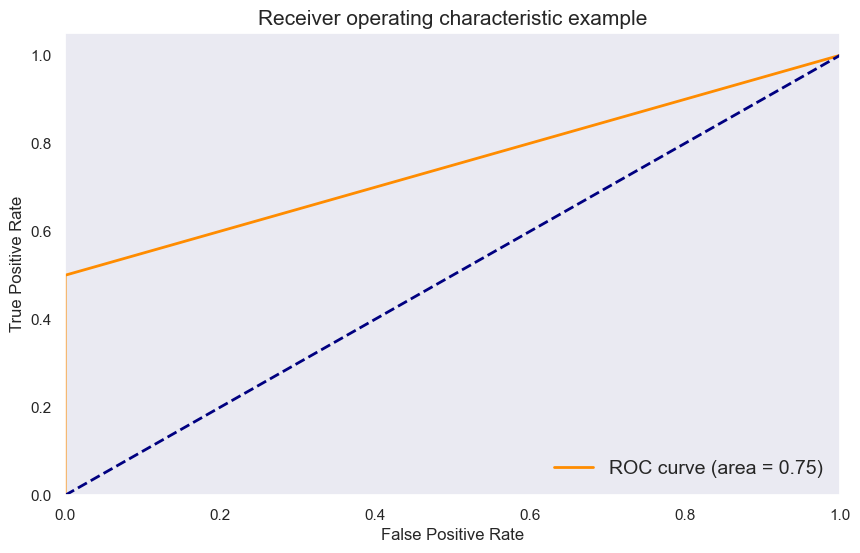

In [ ]:
plot_roc(y_true_2, y_score_2)

In [ ]:
def positive_negative_measurement(y_true, y_score):
    # Initialization
    TRUE_POSITIVE = 0
    FALSE_POSITIVE = 0
    TRUE_NEGATIVE = 0
    FALSE_NEGATIVE = 0
    
    # Calculating the model
    for i in range(len(y_score)):
        if y_true[i] == y_score[i] == 1:
            TRUE_POSITIVE += 1
        if (y_score[i] == 1) and (y_true[i] != y_score[i]):
            FALSE_POSITIVE += 1
        if y_true[i] == y_score[i] == 0:
            TRUE_NEGATIVE += 1
        if (y_score[i] == 0) and (y_true[i] != y_score[i]):
            FALSE_NEGATIVE += 1

    return(TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE)

In [ ]:
TRUE_POSITIVE, FALSE_POSITIVE, TRUE_NEGATIVE, FALSE_NEGATIVE = positive_negative_measurement(y_true_2, y_score_2)
postives_negatives = [[TRUE_POSITIVE, FALSE_POSITIVE], 
                      [FALSE_NEGATIVE, TRUE_NEGATIVE]]

<Axes: >

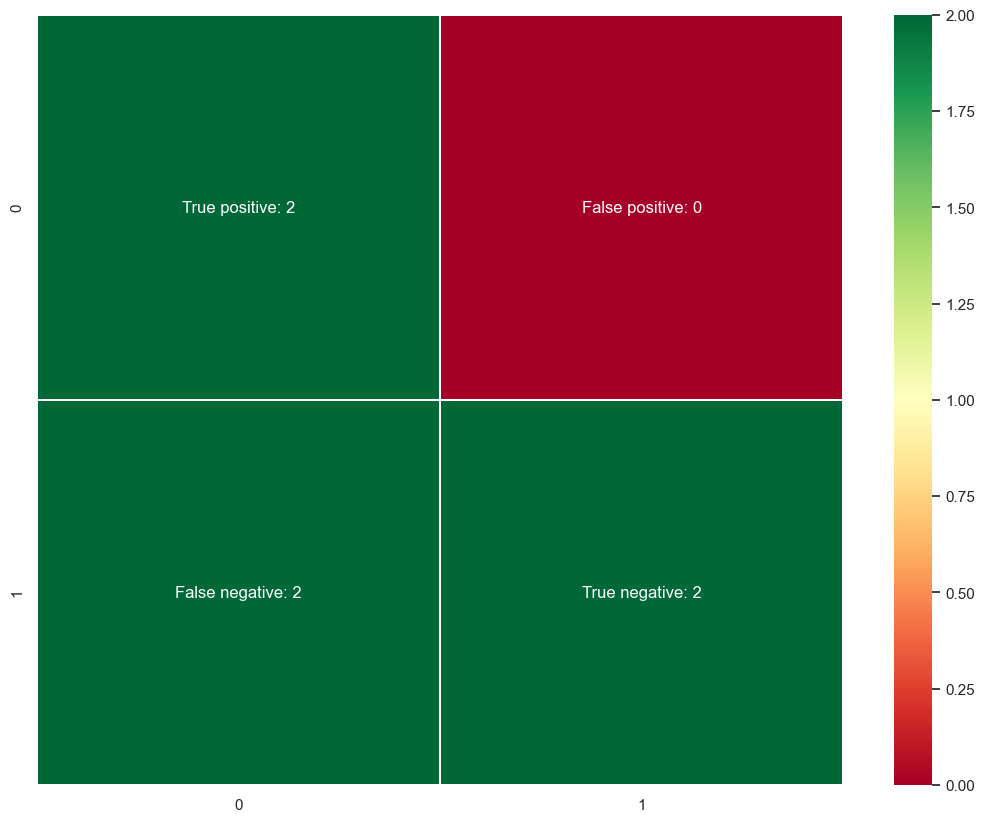

In [ ]:
import seaborn as sns
sns.set()
labels =  np.array([['True positive: ' + str(TRUE_POSITIVE),
                     'False positive: ' + str(FALSE_POSITIVE)],
                    ['False negative: ' + str(FALSE_NEGATIVE),
                     'True negative: ' + str(TRUE_POSITIVE)]])
plt.figure(figsize = (13, 10))
sns.heatmap(postives_negatives, annot = labels, linewidths = 0.1, fmt="", cmap = 'RdYlGn')

In [ ]:
# Sensitivity | Recall | hit rate | true positive rate (TPR)
sensitivity = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_NEGATIVE)
print("Sensitivity: ", sensitivity)

# Specificity | selectivity | true negative rate (TNR)
specifity = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Specifity: ", specifity)

# Precision | positive predictive value (PPV)
# predcision = TRUE_POSITIVE / (TRUE_POSITIVE + FALSE_POSITIVE)
# print("Precision: ", predcision)

# Negative predictive value (NPV)
npv = TRUE_NEGATIVE / (TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Negative predictive value: ", npv)

# Accuracy 
accuracy = (TRUE_POSITIVE + TRUE_NEGATIVE) / (TRUE_POSITIVE + FALSE_POSITIVE + TRUE_NEGATIVE + FALSE_NEGATIVE)
print("Accuracy: ", accuracy)

Sensitivity:  0.5
Specifity:  0.5
Negative predictive value:  0.5
Accuracy:  0.6666666666666666


## 6. Localization

In [ ]:
# Importing the libraries
# from keras.applications.mobilenet import preprocess_input
from tensorflow.keras.applications.mobilenet import preprocess_input
import scipy
import cv2

In [ ]:
path_to_model_weight = "./Saved models/weights.best.mobilenet.hdf5"

In [ ]:
img_path = "ISIC_0032258.jpg"

In [ ]:
def getting_two_layer_weights(path_model_weight = path_to_model_weight):
    # The model

    # Imprting the model
    from keras.applications.mobilenet import MobileNet

    # Pre-build model
    base_model = MobileNet(include_top = False, weights = None, input_shape = (512, 512, 3))

    # Adding output layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(units = 2, activation = 'softmax')(x)

    # Creating the whole model
    model = Model(base_model.input, output)
    #model.summary()

    # Compiling the model
    model.compile(optimizer = Adam(learning_rate = 0.001), 
                  loss = 'categorical_crossentropy', 
                  metrics = ['accuracy'])
    
    # loading the weights
    model.load_weights(path_model_weight)
    
    # Getting the AMP layer weight
    all_amp_layer_weights = model.layers[-1].get_weights()[0]
    
    # Extracting the wanted output
    mobilenet_model = Model(inputs = model.input, outputs = (model.layers[-3].output, model.layers[-1].output))
    
    return mobilenet_model, all_amp_layer_weights

In [ ]:
mobilenet_model, all_amp_layer_weights = getting_two_layer_weights(path_to_model_weight)

In [ ]:
def mobilenet_CAM(img_path, model, all_amp_layer_weights):
    # Getting filtered images from last convolutional layer + model prediction output
    last_conv_output, predictions = model.predict(path_to_tensor(img_path)) # last_conv_output.shape = (1, 16, 16, 1024)
    
    # Converting the dimension of last convolutional layer to 16 x 16 x 1024     
    last_conv_output = np.squeeze(last_conv_output)
    
    # Model's prediction
    predicted_class = np.argmax(predictions)
    
    # Bilinear upsampling (resize each image to size of original image)
    mat_for_mult = scipy.ndimage.zoom(last_conv_output, (32, 32, 1), order = 1)  # dim from (16, 16, 1024) to (512, 512, 1024)
    
    # Getting the AMP layer weights
    amp_layer_weights = all_amp_layer_weights[:, predicted_class] # dim: (1024,)    
    
    # CAM for object class that is predicted to be in the image
    final_output = np.dot(mat_for_mult, amp_layer_weights) # dim: 512 x 512

    # Return class activation map (CAM)
    return final_output, predicted_class

In [ ]:
final_output, predicted_class = mobilenet_CAM(img_path, mobilenet_model, all_amp_layer_weights)

In [ ]:
def plot_CAM(img_path, ax, model, all_amp_layer_weights):
    # Loading the image / resizing to 512x512 / Converting BGR to RGB
    #im = cv2.resize(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB), (512, 512))
    im = path_to_tensor(img_path).astype("float32")/255.
    
    # Plotting the image
    ax.imshow(im.squeeze(), vmin=0, vmax=255)
    
    # Getting the class activation map
    CAM, pred = mobilenet_CAM(img_path, model, all_amp_layer_weights)
    
    CAM = (CAM - CAM.min()) / (CAM.max() - CAM.min())
    
    # Plotting the class activation map
    ax.imshow(CAM, cmap = "jet", alpha = 0.5, interpolation='nearest', vmin=0, vmax=1)

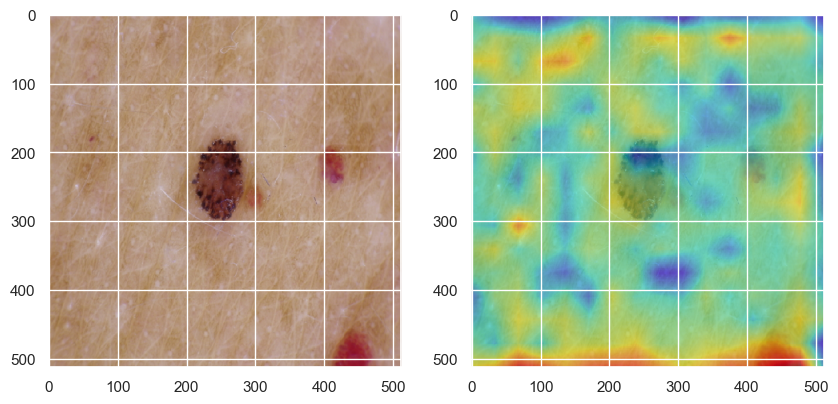

In [ ]:
# Visualizing images with and without localization
# Canvas
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (10, 10))
# Image without localization
ax[0].imshow((path_to_tensor(img_path).astype('float32')/255).squeeze())
# Image with localization
CAM = plot_CAM(img_path, ax[1], mobilenet_model, all_amp_layer_weights)
plt.show()

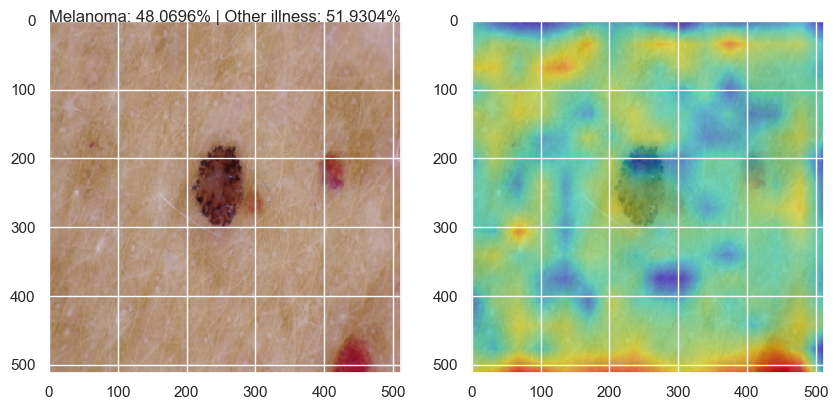

In [ ]:
# Getting the iamge tensor
image_to_predict = path_to_tensor(img_path).astype('float32')/255

# Predicting the image
prediction = ensemble_model.predict(image_to_predict)
prediction_final = "Melanoma: " + str(np.round(prediction[0][0]*100, decimals = 4)) + "%" + \
                   " | Other illness: " + str(np.round(prediction[0][1]*100, decimals = 4)) + "%"

# Canvas initialization
fig = plt.figure(figsize = (10, 10))

# First image
ax = fig.add_subplot(121)
ax.imshow(image_to_predict.squeeze())
ax.text(0.3, 1.6, prediction_final)

# Second image
ax = fig.add_subplot(122)
CAM = plot_CAM(img_path, ax, mobilenet_model, all_amp_layer_weights)

plt.show()